# Unit06 範例演練 01 — 液體摻合問題

本 Notebook 以經典化工液體摻合問題為例，示範如何將物料平衡方程式整理為線性聯立方程組 $\mathbf{Ax}=\mathbf{b}$，並使用 `scipy.linalg.solve()` 求解各槽所需用量。

## 學習目標
- 將化工物料平衡問題轉化為矩陣方程式
- 使用 `np.linalg.matrix_rank()` 判定解的存在性與唯一性
- 使用 `scipy.linalg.solve()` 求解唯一解系統
- 進行殘差驗證、質量守恆檢查與條件數評估
- 以視覺化方式呈現各槽用量分布與摻合結果

**參考來源**：呂維明 (1985)；Cutlip & Shacham (1999)

---
### 0. 環境設定

In [18]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_01\figs


---
### 1. 載入套件

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import linalg

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")


✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
## 2. 問題描述

### 液體摻合問題

某工廠有 **5 個儲存槽**，各槽含有不同體積率之 5 種成分（A、B、C、D、E）。槽號與各成分體積率（%）如下表：

| 槽號 | 成分 A | 成分 B | 成分 C | 成分 D | 成分 E |
|:----:|:------:|:------:|:------:|:------:|:------:|
|  1   |  55.9  |   7.9  |  16.3  |  11.5  |   8.4  |
|  2   |  20.1  |  52.2  |  11.2  |   9.8  |   6.7  |
|  3   |  17.6  |  12.2  |  46.0  |  14.3  |   9.9  |
|  4   |  18.3  |  13.8  |  11.7  |  47.1  |   9.1  |
|  5   |  19.5  |  18.2  |  21.5  |  10.6  |  30.2  |

**顧客需求**：摻合成 **40 公升**產品，各成分體積率（%）須達：A=25%、B=18%、C=23%、D=18%、E=16%。

**問題**：決定各槽所需用量 $V_1, V_2, V_3, V_4, V_5$（公升）。

---

### 數學模型

對每種成分進行體積平衡（在密度不變假設下相當於質量平衡）：

$$
55.9V_1 + 20.1V_2 + 17.6V_3 + 18.3V_4 + 19.5V_5 = 25 \times 40 \quad \text{(成分 A)}
$$

$$
7.9V_1 + 52.2V_2 + 12.2V_3 + 13.8V_4 + 18.2V_5 = 18 \times 40 \quad \text{(成分 B)}
$$

寫成矩陣形式 $\mathbf{Ax} = \mathbf{b}$：

$$
\underbrace{\begin{bmatrix}
55.9 & 20.1 & 17.6 & 18.3 & 19.5 \\
 7.9 & 52.2 & 12.2 & 13.8 & 18.2 \\
16.3 & 11.2 & 46.0 & 11.7 & 21.5 \\
11.5 &  9.8 & 14.3 & 47.1 & 10.6 \\
 8.4 &  6.7 &  9.9 &  9.1 & 30.2
\end{bmatrix}}_{\mathbf{A}}
\underbrace{\begin{bmatrix}V_1\\V_2\\V_3\\V_4\\V_5\end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix}1000\\720\\920\\720\\640\end{bmatrix}}_{\mathbf{b}}
$$

其中 $\mathbf{b} = [25,18,23,18,16]^T \times 40 = [1000,720,920,720,640]^T$，$b_j$ = 目標體積率(%) × 40（採百分率係數之右端向量；實際各成分體積為 10.0、7.2、9.2、7.2、6.4 公升）。

---
## 3. Step 1 — 建構係數矩陣與右端向量

In [20]:
# ============================================================
# Step 1: 建構係數矩陣 A 與右端向量 b
# ============================================================

# 係數矩陣 A：各列 = 一種成分的平衡方程式係數（各槽體積率 %）
#              各行 = 一個儲存槽
A = np.array([
    [55.9, 20.1, 17.6, 18.3, 19.5],   # 成分 A 平衡
    [ 7.9, 52.2, 12.2, 13.8, 18.2],   # 成分 B 平衡
    [16.3, 11.2, 46.0, 11.7, 21.5],   # 成分 C 平衡
    [11.5,  9.8, 14.3, 47.1, 10.6],   # 成分 D 平衡
    [ 8.4,  6.7,  9.9,  9.1, 30.2],   # 成分 E 平衡
], dtype=float)

# 右端向量 b：目標組成 (%) × 40 公升
target_fraction = np.array([25, 18, 23, 18, 16], dtype=float)  # %
total_volume    = 40.0  # 公升
b = target_fraction * total_volume

print("係數矩陣 A (各槽體積率 %):")
print(A)
print(f"\n右端向量 b = 目標組成(%) × {total_volume} 公升:")
print(b)
print(f"\n矩陣形狀: A = {A.shape}, b = {b.shape}")

係數矩陣 A (各槽體積率 %):
[[55.9 20.1 17.6 18.3 19.5]
 [ 7.9 52.2 12.2 13.8 18.2]
 [16.3 11.2 46.  11.7 21.5]
 [11.5  9.8 14.3 47.1 10.6]
 [ 8.4  6.7  9.9  9.1 30.2]]

右端向量 b = 目標組成(%) × 40.0 公升:
[1000.  720.  920.  720.  640.]

矩陣形狀: A = (5, 5), b = (5,)


---
## 4. Step 2 — 秩判定：確認解的存在性與唯一性

使用 Rouché–Capelli 定理判定：

| 條件 | 結論 |
|------|------|
| $\operatorname{rank}(\mathbf{A}) < \operatorname{rank}([\mathbf{A}\mid\mathbf{b}])$ | 無解 |
| $\operatorname{rank}(\mathbf{A}) = \operatorname{rank}([\mathbf{A}\mid\mathbf{b}]) = n$ | **唯一解** |
| $\operatorname{rank}(\mathbf{A}) = \operatorname{rank}([\mathbf{A}\mid\mathbf{b}]) < n$ | 無窮多解 |

In [21]:
# ============================================================
# Step 2: 秩判定
# ============================================================

m, n    = A.shape
rank_A  = np.linalg.matrix_rank(A)
rank_Ab = np.linalg.matrix_rank(np.column_stack([A, b]))

print("=" * 45)
print(f"矩陣維度: {m} 個方程式, {n} 個未知數")
print(f"rank(A)       = {rank_A}")
print(f"rank([A | b]) = {rank_Ab}")
print(f"n             = {n}")
print("-" * 45)

if rank_A < rank_Ab:
    print("→ 無解（方程式互相矛盾）")
elif rank_A == rank_Ab == n:
    print("→ 唯一解 ✓  (rank(A) = rank([A|b]) = n)")
    print("  可使用 scipy.linalg.solve() 求解")
else:
    free = n - rank_A
    print(f"→ 無窮多解（自由度 = {free}）")
    print("  建議使用 scipy.linalg.pinv() 求最小範數解")

# 行列式值（方形矩陣時可計算）
det_A = np.linalg.det(A)
print(f"\ndet(A) = {det_A:.4f}")
print(f"  det(A) ≠ 0 → 係數矩陣可逆，唯一解存在 ✓" if abs(det_A) > 1e-10 else "  det(A) ≈ 0 → 奇異矩陣！")
print("=" * 45)

矩陣維度: 5 個方程式, 5 個未知數
rank(A)       = 5
rank([A | b]) = 5
n             = 5
---------------------------------------------
→ 唯一解 ✓  (rank(A) = rank([A|b]) = n)
  可使用 scipy.linalg.solve() 求解

det(A) = 105976399.1900
  det(A) ≠ 0 → 係數矩陣可逆，唯一解存在 ✓


---
## 5. Step 3 — `scipy.linalg.solve()` 求解各槽用量

In [22]:
# ============================================================
# Step 3: 使用 scipy.linalg.solve() 求唯一解
# ============================================================

V = linalg.solve(A, b)

print("各槽所需用量 (公升):")
print("-" * 30)
for i, v in enumerate(V, 1):
    print(f"  槽 {i} (V{i}): {v:8.4f} 公升")
print("-" * 30)
print(f"  合計:    {V.sum():8.4f} 公升  (目標：{total_volume:.1f} 公升)")

各槽所需用量 (公升):
------------------------------
  槽 1 (V1):   6.6549 公升
  槽 2 (V2):   4.2097 公升
  槽 3 (V3):   8.5016 公升
  槽 4 (V4):   7.1760 公升
  槽 5 (V5):  13.4578 公升
------------------------------
  合計:     40.0000 公升  (目標：40.0 公升)


---
## 6. Step 4 — 解的驗證

驗證包含三項：
1. **數值殘差**：計算 $\|\mathbf{Ax} - \mathbf{b}\|_2$，應為機器精度（$\lesssim 10^{-12}$）
2. **物理合理性**：各槽用量應 $> 0$（不能為負體積）
3. **質量守恆**：各成分計算組成應與目標組成一致；總體積應等於 40 公升


In [23]:
# ============================================================
# Step 4: 解的驗證
# ============================================================
comp_names = ['A', 'B', 'C', 'D', 'E']

print("=" * 55)
print("驗證 1 — 數值殘差")
print("-" * 55)
residual     = np.linalg.norm(A @ V - b)
rel_residual = residual / (np.linalg.norm(A) * np.linalg.norm(V))
cond_A       = np.linalg.cond(A)
print(f"  絕對殘差 ||Ax - b||     = {residual:.4e}")
print(f"  相對殘差               = {rel_residual:.4e}")
print(f"  矩陣條件數 κ(A)        = {cond_A:.4f}")
status = "✓ 良態系統，求解精確" if cond_A < 1e6 else "⚠ 條件數偏大"
print(f"  → {status}")

print("\n驗證 2 — 物理合理性（各槽用量 > 0）")
print("-" * 55)
all_positive = True
for i, v in enumerate(V, 1):
    flag = "✓" if v > 0 else "✗ 負值!"
    print(f"  V{i} = {v:.4f} 公升  {flag}")
    if v <= 0:
        all_positive = False
print(f"  → {'✓ 所有槽用量均為正值，物理上合理' if all_positive else '⚠ 存在負值，請重新確認問題設定'}")

print("\n驗證 3 — 質量守恆與組成匹配")
print("-" * 55)
print(f"  總用量 = {V.sum():.4f} 公升  (目標 {total_volume:.1f} 公升)  "
      + ("✓" if abs(V.sum() - total_volume) < 1e-8 else "⚠"))
print()
actual_vol_L = (A @ V) / 100.0          # 各成分實際體積 (公升) = (組成% × 用量) ÷ 100
actual_frac  = actual_vol_L / total_volume * 100   # 實際組成 (%)
print(f"  {'成分':^4} | {'實際體積(L)':>10} | {'計算組成(%)':>11} | {'目標組成(%)':>11} | 匹配")
print(f"  {'-'*4}-+-{'-'*10}-+-{'-'*11}-+-{'-'*11}-+------")
for j, comp in enumerate(comp_names):
    calc  = actual_frac[j]
    tgt   = target_fraction[j]
    match = "✓" if abs(calc - tgt) < 1e-8 else f"⚠ Δ={calc-tgt:+.4f}"
    print(f"  {comp:^4} | {actual_vol_L[j]:>10.4f} | {calc:>11.4f} | {tgt:>11.2f} | {match}")

print("=" * 55)


驗證 1 — 數值殘差
-------------------------------------------------------
  絕對殘差 ||Ax - b||     = 1.1369e-13
  相對殘差               = 4.8317e-17
  矩陣條件數 κ(A)        = 5.0402
  → ✓ 良態系統，求解精確

驗證 2 — 物理合理性（各槽用量 > 0）
-------------------------------------------------------
  V1 = 6.6549 公升  ✓
  V2 = 4.2097 公升  ✓
  V3 = 8.5016 公升  ✓
  V4 = 7.1760 公升  ✓
  V5 = 13.4578 公升  ✓
  → ✓ 所有槽用量均為正值，物理上合理

驗證 3 — 質量守恆與組成匹配
-------------------------------------------------------
  總用量 = 40.0000 公升  (目標 40.0 公升)  ✓

   成分  |    實際體積(L) |     計算組成(%) |     目標組成(%) | 匹配
  -----+------------+-------------+-------------+------
   A   |    10.0000 |     25.0000 |       25.00 | ✓
   B   |     7.2000 |     18.0000 |       18.00 | ✓
   C   |     9.2000 |     23.0000 |       23.00 | ✓
   D   |     7.2000 |     18.0000 |       18.00 | ✓
   E   |     6.4000 |     16.0000 |       16.00 | ✓


---
## 7. 結果視覺化

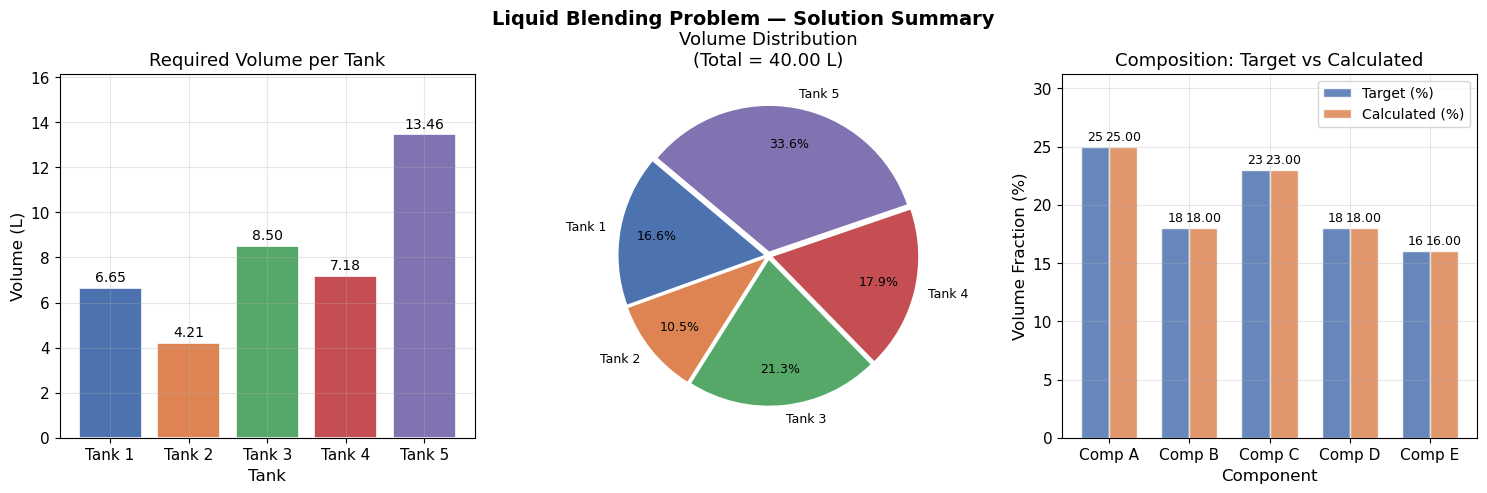

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_01\figs\blending_solution.png


In [24]:
# ============================================================
# 結果視覺化
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Liquid Blending Problem — Solution Summary', fontsize=14, fontweight='bold')

colors_tanks = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

# ─── 子圖 1：各槽用量長條圖 ───
ax = axes[0]
tank_labels = [f'Tank {i}' for i in range(1, 6)]
bars = ax.bar(tank_labels, V, color=colors_tanks, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, V):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{v:.2f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Required Volume per Tank')
ax.set_xlabel('Tank')
ax.set_ylabel('Volume (L)')
ax.set_ylim(0, max(V) * 1.20)

# ─── 子圖 2：各槽用量佔總體積的比例（圓餅圖）───
ax = axes[1]
explode = [0.03] * 5
wedges, texts, autotexts = ax.pie(
    V, labels=tank_labels, autopct='%1.1f%%',
    colors=colors_tanks, explode=explode,
    startangle=140, pctdistance=0.75,
    textprops={'fontsize': 9}
)
ax.set_title(f'Volume Distribution\n(Total = {V.sum():.2f} L)')

# ─── 子圖 3：計算組成 vs 目標組成 ───
ax = axes[2]
x_idx   = np.arange(len(comp_names))
bar_w   = 0.35
b1 = ax.bar(x_idx - bar_w/2, target_fraction, bar_w,
            label='Target (%)', color='#4C72B0', alpha=0.85, edgecolor='white')
b2 = ax.bar(x_idx + bar_w/2, actual_frac, bar_w,
            label='Calculated (%)', color='#DD8452', alpha=0.85, edgecolor='white')
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar, v in zip(b2, actual_frac):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Composition: Target vs Calculated')
ax.set_xlabel('Component')
ax.set_ylabel('Volume Fraction (%)')
ax.set_xticks(x_idx)
ax.set_xticklabels([f'Comp {c}' for c in comp_names])
ax.set_ylim(0, max(target_fraction) * 1.25)
ax.legend()

plt.tight_layout()
fig_path = FIG_DIR / 'blending_solution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存至: {fig_path}")
